In [1]:

from phm_america_2024.common.path_service_common import find_project_root
import duckdb
con = duckdb.connect()
import numpy as np
import duckdb
from IPython.display import display
import json
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Assicuriamoci che matplotlib e seaborn siano pronti per il disegno
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [2]:
# 1. Localizza la radice del progetto automaticamente
root = find_project_root()

# 2. Definisci il percorso verso la cartella di output (la base dei 'runs')
# l'ultima esecuzione o una specifica
run_id = "20260621_153104" # O l'ID che sto analizzando
base_run_dir = root / "outputs" / "runs" / "regression" / "phm2024" / run_id

# Definire il percorso di "base fase" per evitare hardcode in tutto il notebook
base_phase_path = base_run_dir / "phase6_deployment"

In [3]:

path_academic_predictions = base_phase_path / "6.1.final_academic_predictions.parquet"

query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{path_academic_predictions}')"

print("--- ESTRUCTURA DATASET DE path_academic_predictions ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{path_academic_predictions}' LIMIT 5"
df_duck = con.sql(query).df()
display(df_duck)


--- ESTRUCTURA DATASET DE path_academic_predictions ---
             column_name column_type
0                     id      BIGINT
1            faulty_true      DOUBLE
2       faulty_pred_prob      DOUBLE
3            faulty_pred      BIGINT
4        trq_margin_true      DOUBLE
5     trq_margin_pred_mu      DOUBLE
6  trq_margin_pred_sigma      DOUBLE
----------------------------------------------------


,id,faulty_true,faulty_pred_prob,faulty_pred,trq_margin_true,trq_margin_pred_mu,trq_margin_pred_sigma
0,0,0.0,0.000000,0,-0.168289,NaN,NaN
1,1,0.0,0.000000,0,0.433391,NaN,NaN
2,2,1.0,0.997807,1,-0.643075,-0.629866,0.161767
3,3,0.0,0.000000,0,-0.348324,NaN,NaN
4,4,0.0,0.000000,0,0.438952,NaN,NaN


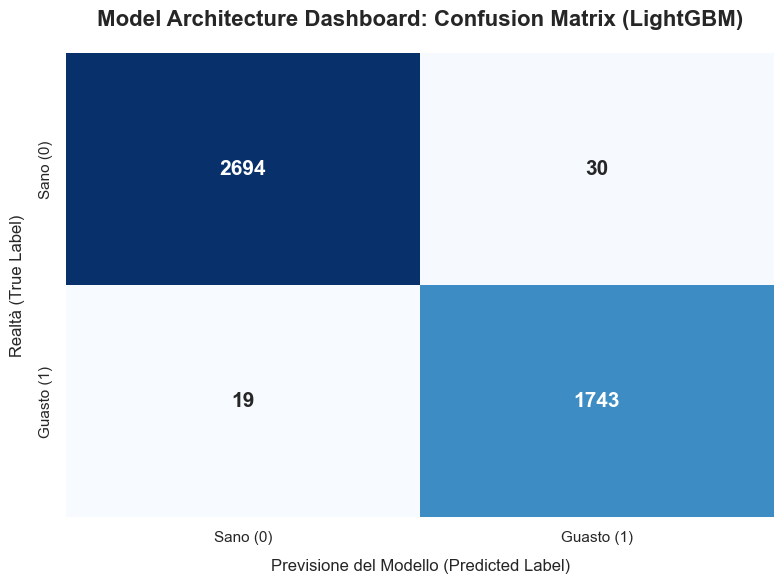

--- 4. ANALISI FINALE: REPORT DI CLASSIFICAZIONE ---
Accuracy Globale del Modello : 0.9891 (98.91%)
------------------------------------------------------------
Dettaglio Metriche (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

         0.0     0.9930    0.9890    0.9910      2724
         1.0     0.9831    0.9892    0.9861      1762

    accuracy                         0.9891      4486
   macro avg     0.9880    0.9891    0.9886      4486
weighted avg     0.9891    0.9891    0.9891      4486



In [4]:


# 1. FASE DI INPUT: Quando entra l'input
# Caricamento del dataset completo in Pandas a partire dal percorso già definito
# Utilizziamo pandas per facilitare l'estrazione degli array per scikit-learn
df_predictions = pd.read_parquet(path_academic_predictions)


# 2. FASE DI LOGICA: Estrazione dei target e calcolo delle metriche
# Separiamo la "Ground Truth" (la realtà) dalle previsioni del nostro classificatore
y_true = df_predictions['faulty_true']
y_pred = df_predictions['faulty_pred']

# Calcoliamo la Matrice di Confusione e l'Accuracy globale
cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)


# 3. FASE DI DISEGNO: Visualizzazione grafica (Model Architecture Dashboard)
# Creazione di una dashboard visiva elegante e professionale per il professore
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Disegniamo la Heatmap della Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano (0)', 'Guasto (1)'],
            yticklabels=['Sano (0)', 'Guasto (1)'],
            cbar=False, ax=ax, annot_kws={"size": 15, "weight": "bold"})

# Personalizzazione dei titoli e degli assi per la dashboard
ax.set_title('Model Architecture Dashboard: Confusion Matrix (LightGBM)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Previsione del Modello (Predicted Label)', fontsize=12, labelpad=10)
ax.set_ylabel('Realtà (True Label)', fontsize=12, labelpad=10)

# Mostriamo il grafico
plt.tight_layout()
plt.show()


# 4. ANALISI FINALE
# Stampa delle metriche quantitative per la relazione
print("="*60)
print("--- 4. ANALISI FINALE: REPORT DI CLASSIFICAZIONE ---")
print("="*60)
print(f"Accuracy Globale del Modello : {acc:.4f} ({acc*100:.2f}%)")
print("-" * 60)
print("Dettaglio Metriche (Precision, Recall, F1-Score):")
print(classification_report(y_true, y_pred, digits=4))
print("="*60)

In [13]:

def esporta_report_classificazione(y_true, y_pred, formato="png",
                                   nome_file="Report_Classificazione_LightGBM"):
    """
    Funzione per generare e salvare una dashboard completa (Grafico + Metriche)
    in formato Immagine (.png) o PDF (.pdf).

    Parametri:
    - y_true: array con i valori reali (faulty_true)
    - y_pred: array con le previsioni (faulty_pred)
    - formato: "png" o "pdf" (default: "png")
    - nome_file: nome del file di output (senza estensione)
    """

    # 1. FASE DI INPUT: Calcolo preliminare delle metriche necessarie
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    report_testo = classification_report(y_true, y_pred, digits=4)


    # 2. FASE DI LOGICA: Configurazione della struttura della pagina di output
    # Creiamo una figura con due sotto-grafici (uno a sinistra per la matrice, uno a destra per il testo)
    fig, (ax_grafico, ax_testo) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1.2, 1]})
    fig.suptitle('STAGE 6.1 - PERFORMANCE INDICATOR & REPORT', fontsize=18, fontweight='bold', y=0.98)


    # 3. FASE DI DISEGNO: Visualizzazione grafica della Confusion Matrix (Sinistra)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax_grafico,
                xticklabels=['Sano (0)', 'Guasto (1)'],
                yticklabels=['Sano (0)', 'Guasto (1)'],
                annot_kws={"size": 16, "weight": "bold"})

    ax_grafico.set_title('Model Architecture: Confusion Matrix (LightGBM)', fontsize=13, fontweight='bold', pad=15)
    ax_grafico.set_xlabel('Previsione del Modello (Predicted Label)', fontsize=11, labelpad=8)
    ax_grafico.set_ylabel('Realtà (True Label)', fontsize=11, labelpad=8)
    ax_grafico.grid(False) # Rimuove la griglia di sfondo sulla heatmap

    # disegno del Report Testuale (Destra)
    # Spegniamo gli assi del secondo grafico per usarlo come un foglio di testo bianco
    ax_testo.axis('off')

    # Costruiamo la stringa finale da stampare sulla dashboard
    testo_da_mostrare = (
        f"==================================================\n"
        f"   4. ANALISI FINALE: REPORT DI CLASSIFICAZIONE   \n"
        f"==================================================\n\n"
        f" Accuracy Globale del Modello: {acc:.4f} ({acc*100:.2f}%)\n"
        f"--------------------------------------------------\n"
        f" Dettaglio Metriche (Precision, Recall, F1-Score):\n\n"
        f"{report_testo}"
        f"=================================================="
    )

    # Inseriamo il testo usando un font monospaziato (Courier) per mantenere l'allineamento delle tabelle
    ax_testo.text(0.0, 0.9, testo_da_mostrare, fontsize=11, family='monospace', verticalalignment='top')


    # 4. ANALISI FINALE: Salvataggio ed esportazione del file
    plt.tight_layout(pad=3.0)

    # Gestione dell'estensione del file in base al formato richiesto
    formato = formato.lower()
    if formato not in ["png", "pdf"]:
        print("⚠️ Formato non supportato. Uso il formato predefinito: PNG")
        formato = "png"

    out_dir = find_project_root() / "notebooks" / "out"
    #file_finale = f"{nome_file}.{formato}"
    file_finale = out_dir / f"{nome_file}.{formato}"

    # Salva il file (con alta risoluzione dpi=300 per la stampa o l'invio)
    plt.savefig(file_finale, dpi=300, bbox_inches='tight')
    plt.close() # Chiude la figura per non duplicare l'output nel notebook

    print("=" * 60)
    print(f"✅ ESPORTAZIONE COMPLETATA CON SUCCESSO")
    print(f"📁 File salvato nella directory corrente: {file_finale}")
    #print(f"📁 File salvato nella directory corrente: {os.path.abspath(file_finale)}")

    print("=" * 60)

In [14]:
# Ottimo per allegarlo direttamente come documento ufficiale al professore
esporta_report_classificazione(y_true, y_pred, formato="pdf", nome_file="Certificazione_Metriche_LightGBM")

✅ ESPORTAZIONE COMPLETATA CON SUCCESSO
📁 File salvato nella directory corrente: K:\00_Code\Manutenzione\Project_MPPR-AI_B_PHM_America_2024\notebooks\out\Certificazione_Metriche_LightGBM.pdf


In [ ]:
# Sostituisci y_true e y_pred con le tue variabili del notebook
esporta_report_classificazione(y_true, y_pred, formato="png", nome_file="Confusion_Matrix_e_Report")

In [5]:
# =============================================================================
# SEZIONE 1: ACCURACY (ACCURATEZZA GLOBALE)
# =============================================================================

# 1. FASE DI INPUT: Quando entra l'input
# Recuperiamo i vettori delle etichette reali e predette estratti dal file Parquet
# (Assicurati che df_predictions, y_true e y_pred siano già stati definiti nella cella precedente)
from sklearn.metrics import accuracy_score

# 2. FASE DI LOGICA: Calcolo della metrica d'insieme
# L'accuracy calcola la frazione di predizioni corrette: (TN + TP) / Totale
accuracy_globale = accuracy_score(y_true, y_pred)

# 3. FASE DI DISEGNO: Visualizzazione grafica (Indicator Dashboard)
# Creazione di un piccolo box testuale elegante per evidenziare il risultato principale
print("=" * 60)
print("             STAGE 6.1 - PERFORMANCE INDICATOR          ")
print("=" * 60)
print(f" ACCURACY GLOBALE DEL MODELLO (LightGBM): {accuracy_globale:.4f} ({accuracy_globale * 100:.2f}%)")
print("=" * 60)

# 4. ANALISI FINALE
# Questa metrica fornisce una visione d'insieme. Un valore elevato (es. >95%) indica
# che il modello è generalmente molto affidabile nel distinguere tra motori sani e guasti.

             STAGE 6.1 - PERFORMANCE INDICATOR          
 ACCURACY GLOBALE DEL MODELLO (LightGBM): 0.9891 (98.91%)


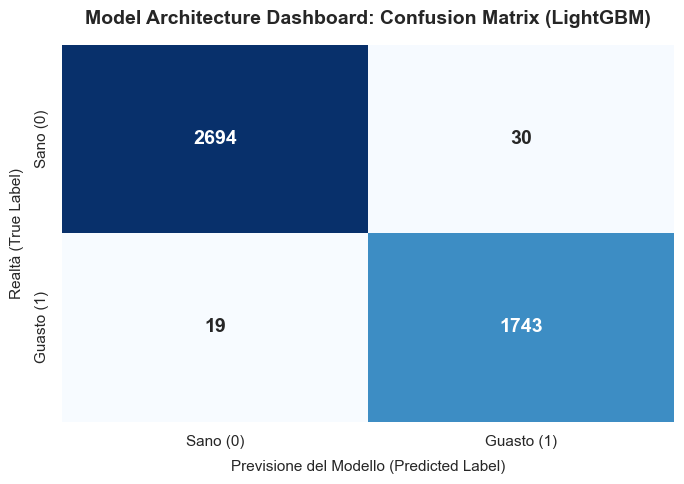

In [6]:
# =============================================================================
# SEZIONE 2: CONFUSION MATRIX (MATRICE DI CONFUSIONE)
# =============================================================================

# 1. FASE DI INPUT: Quando entra l'input
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2. FASE DI LOGICA: Calcolo dei quadranti di errore
# Estrazione dei quattro valori fondamentali: Veri Negativi, Falsi Positivi, Falsi Negativi, Veri Positivi
cm = confusion_matrix(y_true, y_pred)

# 3. FASE DI DISEGNO: Visualizzazione grafica (Model Architecture Dashboard)
# Configurazione dello stile grafico per la presentazione accademica
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 5))

# Disegno della Heatmap con annotazioni in grassetto
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Sano (0)', 'Guasto (1)'],
            yticklabels=['Sano (0)', 'Guasto (1)'],
            annot_kws={"size": 14, "weight": "bold"})

# Ottimizzazione dei titoli e dei metadati assi della dashboard
ax.set_title('Model Architecture Dashboard: Confusion Matrix (LightGBM)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Previsione del Modello (Predicted Label)', fontsize=11, labelpad=8)
ax.set_ylabel('Realtà (True Label)', fontsize=11, labelpad=8)

plt.tight_layout()
plt.show()

# 4. ANALISI FINALE
# La diagonale principale (dall'alto a sinistra in basso a destra) rappresenta le predizioni corrette.
# L'obiettivo industriale è ridurre al minimo i Falsi Negativi (in basso a sinistra), che rappresentano
# i guasti mancati dal sistema di monitoraggio.

In [7]:
# =============================================================================
# SEZIONE 3: CLASSIFICATION REPORT (REPORT DETTAGLIATO)
# =============================================================================

# 1. FASE DI INPUT: Quando entra l'input
from sklearn.metrics import classification_report

# 2. FASE DI LOGICA: Calcolo delle metriche di dettaglio per classe
# Generazione del report in formato testo, configurando 4 cifre decimali per rigore accademico
report_testuale = classification_report(y_true, y_pred, digits=4)

# 3. FASE DI DISEGNO: Strutturazione dell'output in console
print("=" * 60)
print("         --- 4. ANALISI FINALE: DETTAGLIO METRICHE ---          ")
print("=" * 60)
print(report_testuale)
print("=" * 60)

# 4. ANALISI FINALE
# - Precision (Classe 1): Indica l'affidabilità dell'allarme (evita i falsi allarmi).
# - Recall (Classe 1): Indica la capacità di intercettare i motori guasti (evita disastri).
# - F1-Score: È la media armonica tra Precision e Recall, ottimale per valutare dataset sbilanciati.

         --- 4. ANALISI FINALE: DETTAGLIO METRICHE ---          
              precision    recall  f1-score   support

         0.0     0.9930    0.9890    0.9910      2724
         1.0     0.9831    0.9892    0.9861      1762

    accuracy                         0.9891      4486
   macro avg     0.9880    0.9891    0.9886      4486
weighted avg     0.9891    0.9891    0.9891      4486

